In [17]:
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_J

#***** Define stellar properties *****#

R_s = 1.155*R_Sun     # Stellar radius (m)
T_s = 6071.0          # Stellar effective temperature (K)
Met_s = 0.0           # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.38        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s)

#***** Define planet properties *****#

planet_name = 'WASP-999b'  # Planet name used for plots, output files etc.

R_p = 1.359*R_J     # Planetary radius (m)
g_p = 9.186         # Gravitational field of planet (m/s^2)
T_eq = 1400.0       # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, gravity = g_p, T_eq = T_eq)

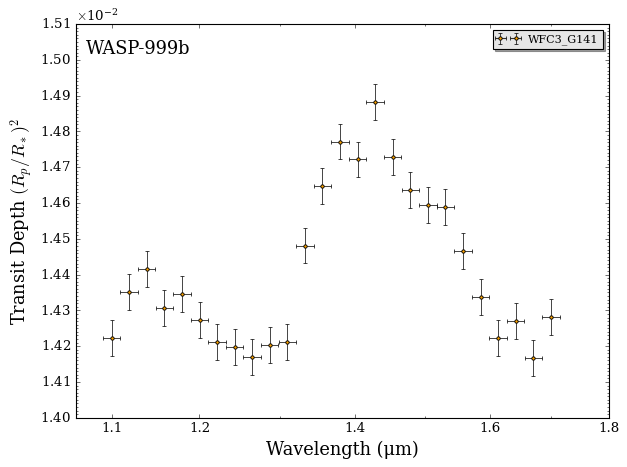

In [18]:
from POSEIDON.core import load_data, wl_grid_constant_R
from POSEIDON.visuals import plot_data

#***** Model wavelength grid *****#

wl_min = 0.4      # Minimum wavelength (um)
wl_max = 3.0      # Maximum wavelength (um)
R = 4000         # Spectral resolution of grid

# We need to provide a model wavelength grid to initialise instrument properties
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Specify data location and instruments  *****#

data_dir = './POSEIDON/reference_data/observations/WASP-999b'         # Change this to where your data is stored
datasets = ['WASP-999b_WFC3_G141.dat']  # Found in reference_data/observations
instruments = ['WFC3_G141']             # Instruments corresponding to the data

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)

# Plot our data
fig_data = plot_data(data, planet_name)

In [19]:
data

{'datasets': array(['WASP-999b_WFC3_G141.dat'], dtype='<U23'),
 'instruments': array(['WFC3_G141'], dtype='<U9'),
 'wl_data': array([1.1     , 1.119322, 1.138983, 1.158989, 1.179347, 1.200063,
        1.221142, 1.242592, 1.264418, 1.286628, 1.309228, 1.332225,
        1.355625, 1.379437, 1.403667, 1.428323, 1.453412, 1.478941,
        1.504919, 1.531353, 1.558252, 1.585623, 1.613475, 1.641816,
        1.670655, 1.7     ]),
 'half_bin': array([0.009661, 0.009661, 0.009831, 0.010003, 0.010179, 0.010358,
        0.01054 , 0.010725, 0.010913, 0.011105, 0.0113  , 0.011498,
        0.0117  , 0.011906, 0.012115, 0.012328, 0.012544, 0.012765,
        0.012989, 0.013217, 0.013449, 0.013686, 0.013926, 0.014171,
        0.014419, 0.014673]),
 'ydata': array([0.01422258, 0.01435198, 0.0144159 , 0.01430605, 0.01434545,
        0.01427396, 0.01421073, 0.01419839, 0.01416885, 0.01420429,
        0.01421221, 0.01448098, 0.01464663, 0.01477155, 0.01472171,
        0.01488308, 0.01472939, 0.01463625, 0.

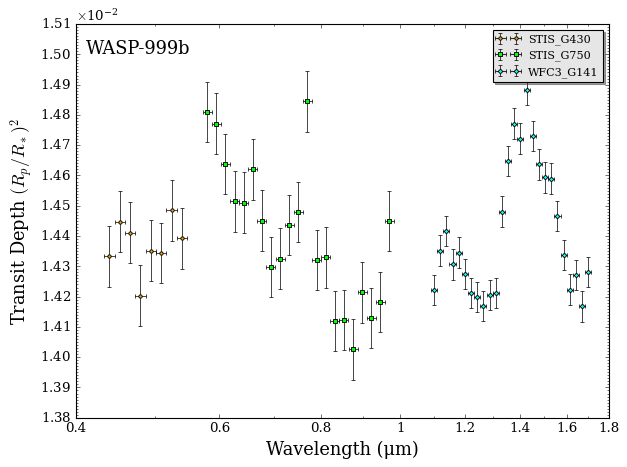

In [3]:
# Specify the STIS and WFC3 Hubble data
data_dir = './POSEIDON/reference_data/observations/WASP-999b'
datasets = ['WASP-999b_STIS_G430.dat',
            'WASP-999b_STIS_G750.dat',
            'WASP-999b_WFC3_G141.dat']
instruments = ['STIS_G430', 'STIS_G750', 'WFC3_G141']

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, instruments, wl)

# Plot our data
fig_data = plot_data(data, planet_name)

In [4]:
from POSEIDON.core import define_model

#***** Define model *****#

model_name = 'My_first_retrieval'  # Model name used for plots, output files etc.

bulk_species = ['H2', 'He']     # H2 + He comprises the bulk atmosphere
param_species = ['H2O']         # The only trace gas is H2O

# Create the model object
model = define_model(model_name, bulk_species, param_species,
                     PT_profile = 'isotherm', cloud_model = 'cloud-free')

# Check the free parameters defining this model
print("Free parameters: " + str(model['param_names']))

Free parameters: ['R_p_ref' 'T' 'log_H2O']


In [5]:
from POSEIDON.core import set_priors

#***** Set priors for retrieval *****#

# Initialise prior type dictionary
prior_types = {}

# Specify whether priors are linear, Gaussian, etc.
prior_types['T'] = 'uniform'
prior_types['R_p_ref'] = 'uniform'
prior_types['log_H2O'] = 'uniform'

# Initialise prior range dictionary
prior_ranges = {}

# Specify prior ranges for each free parameter
prior_ranges['T'] = [400, 1600]
prior_ranges['R_p_ref'] = [0.85*R_p, 1.15*R_p]
prior_ranges['log_H2O'] = [-12, -1]

# Create prior object for retrieval
priors = set_priors(planet, star, model, data, prior_types, prior_ranges)

In [6]:
from POSEIDON.core import read_opacities
import numpy as np

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 400     # Same as prior range for T
T_fine_max = 1600    # Same as prior range for T
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step),
                       log_P_fine_step)

# Pre-interpolate the opacities
opac = read_opacities(model, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2O done
Opacity pre-interpolation complete.


In [7]:
from POSEIDON.retrieval import run_retrieval

#***** Specify fixed atmospheric settings for retrieval *****#

# Atmospheric pressure grid
P_min = 1.0e-7    # 0.1 ubar
P_max = 100       # 100 bar
N_layers = 100    # 100 layers

# Let's space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

# Specify the reference pressure
P_ref = 10.0   # Retrieved R_p_ref parameter will be the radius at 10 bar

#***** Run atmospheric retrieval *****#

run_retrieval(planet, star, model, opac, data, priors, wl, P, P_ref, R = R,
              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',
              N_live = 400, verbose = True)

POSEIDON now running 'My_first_retrieval'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    3
 *****************************************************
 Starting MultiNest
 generating live points
 live points generated, starting sampling
Acceptance Rate:                        0.995575
Replacements:                                450
Total Samples:                               452
Nested Sampling ln(Z):            -134337.220733
Acceptance Rate:                        0.963391
Replacements:                                500
Total Samples:                               519
Nested Sampling ln(Z):             -83328.074252
Acceptance Rate:                        0.941781
Replacements:                                550
Total Samples:                               584
Nested Sampling ln(Z):             -62674.857910
Acceptance Rate:                        0.916031
R

Generating corner plot ...


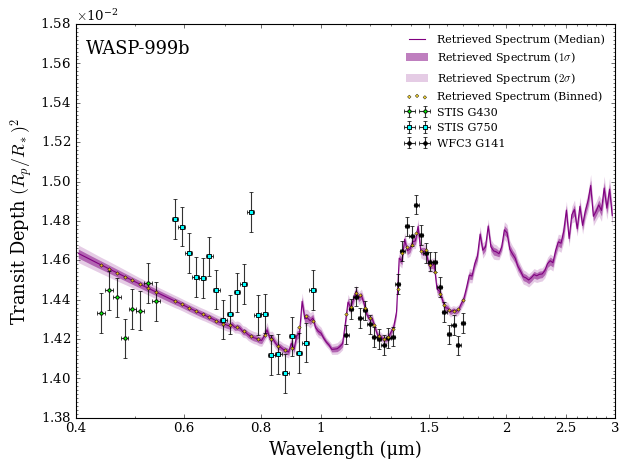

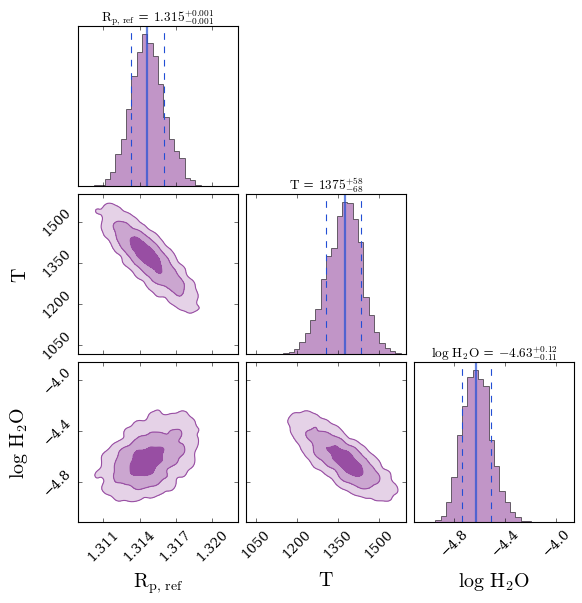

In [8]:
from POSEIDON.utility import read_retrieved_spectrum, plot_collection
from POSEIDON.visuals import plot_spectra_retrieved
from POSEIDON.corner import generate_cornerplot

#***** Plot retrieved transmission spectrum *****#

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name)

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'],
                                  data_colour_list = ['lime', 'cyan', 'black'])

#***** Make corner plot *****#

fig_corner = generate_cornerplot(planet, model)

In [9]:
#***** Define new model *****#

model_name_2 = 'Improved_retrieval'

bulk_species = ['H2', 'He']
param_species_2 = ['Na', 'K', 'TiO', 'H2O']  # Three new chemical species added

# Create the model object
model_2 = define_model(model_name_2, bulk_species, param_species_2,
                       PT_profile = 'isotherm', cloud_model = 'cloud-free')

# Check the free parameters defining this model
print("Free parameters: " + str(model_2['param_names']))

#***** Set priors for new retrieval *****#

# Initialise prior type dictionary
prior_types_2 = {}

# Specify whether priors are linear, Gaussian, etc.
prior_types_2['T'] = 'uniform'
prior_types_2['R_p_ref'] = 'uniform'
prior_types_2['log_X'] = 'uniform'    # 'log_X' sets the same prior for all mixing ratios

# Initialise prior range dictionary
prior_ranges_2 = {}

# Specify prior ranges for each free parameter
prior_ranges_2['T'] = [400, 1600]
prior_ranges_2['R_p_ref'] = [0.85*R_p, 1.15*R_p]
prior_ranges_2['log_X'] = [-12, -1]   # 'log_X' sets the same prior for all mixing ratios

# Create prior object for retrieval
priors_2 = set_priors(planet, star, model_2, data, prior_types_2, prior_ranges_2)

#***** Read opacity data *****#

# Pre-interpolate the opacities
opac_2 = read_opacities(model_2, wl, opacity_treatment, T_fine, log_P_fine)

#***** Run atmospheric retrieval *****#

run_retrieval(planet, star, model_2, opac_2, data, priors_2, wl, P, P_ref, R = R,
              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',
              N_live = 400, verbose = False)   # This last variable suppresses MultiNest terminal output

Free parameters: ['R_p_ref' 'T' 'log_Na' 'log_K' 'log_TiO' 'log_H2O']
Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
Na done
K done
TiO done
H2O done
Opacity pre-interpolation complete.
POSEIDON now running 'Improved_retrieval'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    6
 *****************************************************
POSEIDON retrieval finished in 0.2 hours ln(ev)=   430.36689864134570      +/-  0.19484508893334745     
 Total Likelihood Evaluations:        27617
 Sampling finished. Exiting MultiNest

Now generating 1000 sampled spectra and P-T profiles from the posterior distribution...
This process will take approximately 0.42 minutes
All done! Output files can be found in ./POSEIDON_output/WASP-999b/retrievals/results/


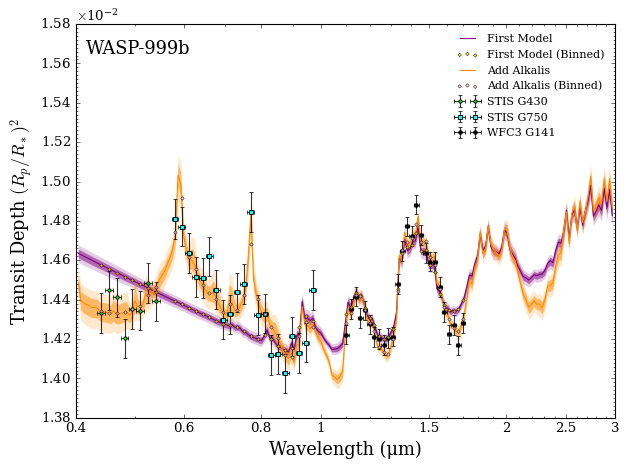

In [10]:
#***** Plot retrieved transmission spectrum *****#

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_name_2)

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  spectra_labels = ['First Model', 'Add Alkalis'],
                                  data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'],
                                  data_colour_list = ['lime', 'cyan', 'black'])

Generating corner plot ...


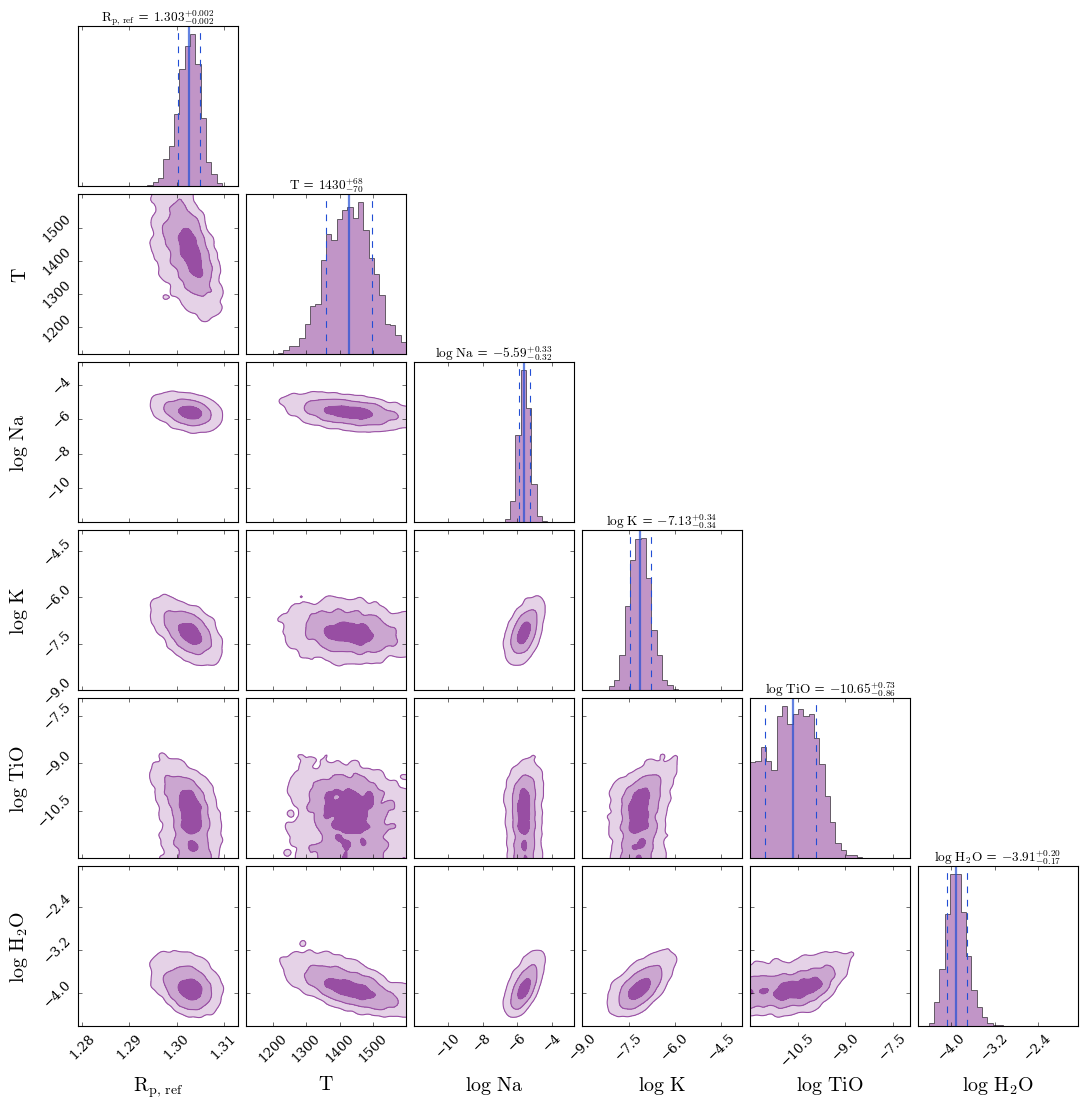

In [11]:
fig_corner = generate_cornerplot(planet, model_2)

In [12]:
#***** Define nested models *****#

model_name_3 = 'No_H2O'
model_name_4 = 'No_TiO'

param_species_3 = ['Na', 'K', 'TiO']  # No H2O
param_species_4 = ['Na', 'K', 'H2O']  # No TiO

# Create the model objects
model_3 = define_model(model_name_3, bulk_species, param_species_3,
                       PT_profile = 'isotherm', cloud_model = 'cloud-free')
model_4 = define_model(model_name_4, bulk_species, param_species_4,
                       PT_profile = 'isotherm', cloud_model = 'cloud-free')

# We can use the same priors as model 2 (since we used the same prior for all mixing ratios)

#***** Read opacity data *****#

# Pre-interpolate the opacities
opac_3 = read_opacities(model_3, wl, opacity_treatment, T_fine, log_P_fine)
opac_4 = read_opacities(model_4, wl, opacity_treatment, T_fine, log_P_fine)

#***** Run atmospheric retrievals *****#

# Retrieval with no H2O
run_retrieval(planet, star, model_3, opac_3, data, priors_2, wl, P, P_ref, R = R,   # Same priors as the reference model
              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',
              N_live = 400, verbose = False)

# Retrieval with no TiO
run_retrieval(planet, star, model_4, opac_4, data, priors_2, wl, P, P_ref, R = R,   # Same priors as the reference model
              spectrum_type = 'transmission', sampling_algorithm = 'MultiNest',
              N_live = 400, verbose = False)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
Na done
K done
TiO done
Opacity pre-interpolation complete.
Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
Na done
K done
H2O done
Opacity pre-interpolation complete.
POSEIDON now running 'No_H2O'
 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    5
 *****************************************************

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest Warning!
 Parameter            2  of mode            1  is converging towards the edge of the prior.

 MultiNest 

In [13]:
from POSEIDON.retrieval import Bayesian_model_comparison

# Rename the models just for convenience
model_ref = model_2
model_no_H2O = model_3
model_no_TiO = model_4

# H2O model comparison
Bayesian_model_comparison(planet_name, model_ref, model_no_H2O)

Bayesian evidences:

Model Improved_retrieval: ln Z = 430.37 +/- 0.19
Model No_H2O: ln Z = 164.15 +/- 0.19

Bayes factor:

B = 4.12e+115
ln B = 266.21

'Equivalent' detection significance:

23.2 σ



In [14]:
# TiO model comparison
Bayesian_model_comparison(planet_name, model_ref, model_no_TiO)

Bayesian evidences:

Model Improved_retrieval: ln Z = 430.37 +/- 0.19
Model No_TiO: ln Z = 430.96 +/- 0.19

Bayes factor:

B = 5.50e-01
ln B = -0.60

No detection of the reference model, model No_TiO is preferred.



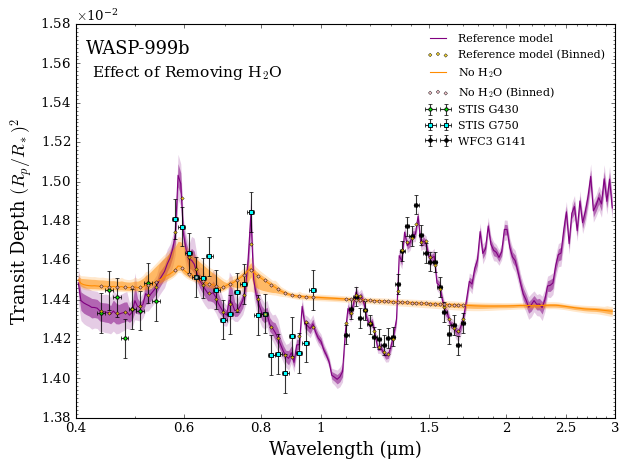

In [15]:
# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_ref['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_no_H2O['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  spectra_labels = ['Reference model', 'No H$_2$O'],
                                  data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'],
                                  data_colour_list = ['lime', 'cyan', 'black'],
                                  plt_label = 'Effect of Removing H$_2$O')

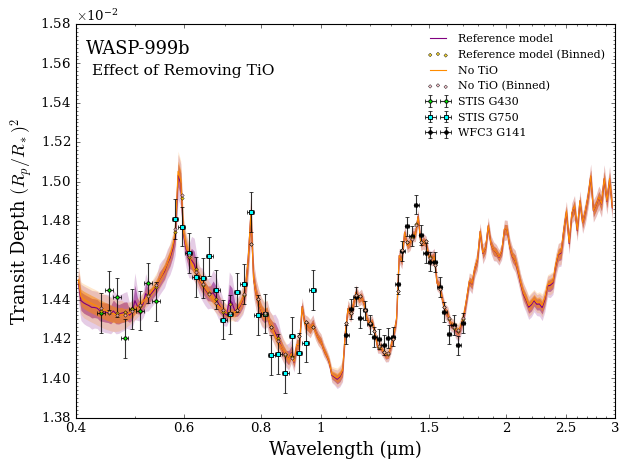

In [16]:
# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_ref['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = [])
spectra_low1 = plot_collection(spec_low1, wl, collection = [])
spectra_low2 = plot_collection(spec_low2, wl, collection = [])
spectra_high1 = plot_collection(spec_high1, wl, collection = [])
spectra_high2 = plot_collection(spec_high2, wl, collection = [])

# Read retrieved spectrum confidence regions
wl, spec_low2, spec_low1, spec_median, \
spec_high1, spec_high2 = read_retrieved_spectrum(planet_name, model_no_TiO['model_name'])

# Create composite spectra objects for plotting
spectra_median = plot_collection(spec_median, wl, collection = spectra_median)
spectra_low1 = plot_collection(spec_low1, wl, collection = spectra_low1)
spectra_low2 = plot_collection(spec_low2, wl, collection = spectra_low2)
spectra_high1 = plot_collection(spec_high1, wl, collection = spectra_high1)
spectra_high2 = plot_collection(spec_high2, wl, collection = spectra_high2)

# Produce figure
fig_spec = plot_spectra_retrieved(spectra_median, spectra_low2, spectra_low1,
                                  spectra_high1, spectra_high2, planet_name,
                                  data, R_to_bin = 100,
                                  spectra_labels = ['Reference model', 'No TiO'],
                                  data_labels = ['STIS G430', 'STIS G750', 'WFC3 G141'],
                                  data_colour_list = ['lime', 'cyan', 'black'],
                                  plt_label = 'Effect of Removing TiO')